In [1]:

import os
def _fix_devices(num_devices):
    os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={num_devices}"
    os.environ["JAX_PLATFORMS"] = "cpu"
    os.environ["JAX_PLATFORM_NAME"] = "cpu"
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    return None

_fix_devices(4)

import jax.numpy as jnp
os.chdir("./src")  

from agent import Agent
from environment.h2_export_2 import H2ExportEnvironmentTwoArg as H2ExportEnvironment

solve_date = "2026-02-11"
solve_id = "16-23-56"#  12:53 - 06:55 <-> took ~ 18 hours

c:\Users\cameronA\AppData\Local\miniconda3\envs\mu_F\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-12 08:57:33,063	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:

agent = Agent(solve_date=solve_date, solve_id=solve_id)
env = H2ExportEnvironment(solve_date=solve_date, solve_id=solve_id)

[INFO]: Action taken at node 0: [4967.3745 4827.9556]. Using value function
[INFO]: Action taken at node 1: [4420.8125 3062.52  ]. Using value function
[INFO]: Action taken at node 2: [4532.7236 3577.9075]. Using value function
[INFO]: Action taken at node 3: [3666.3667 1744.1318]. Using value function


<Figure size 3500x3500 with 0 Axes>

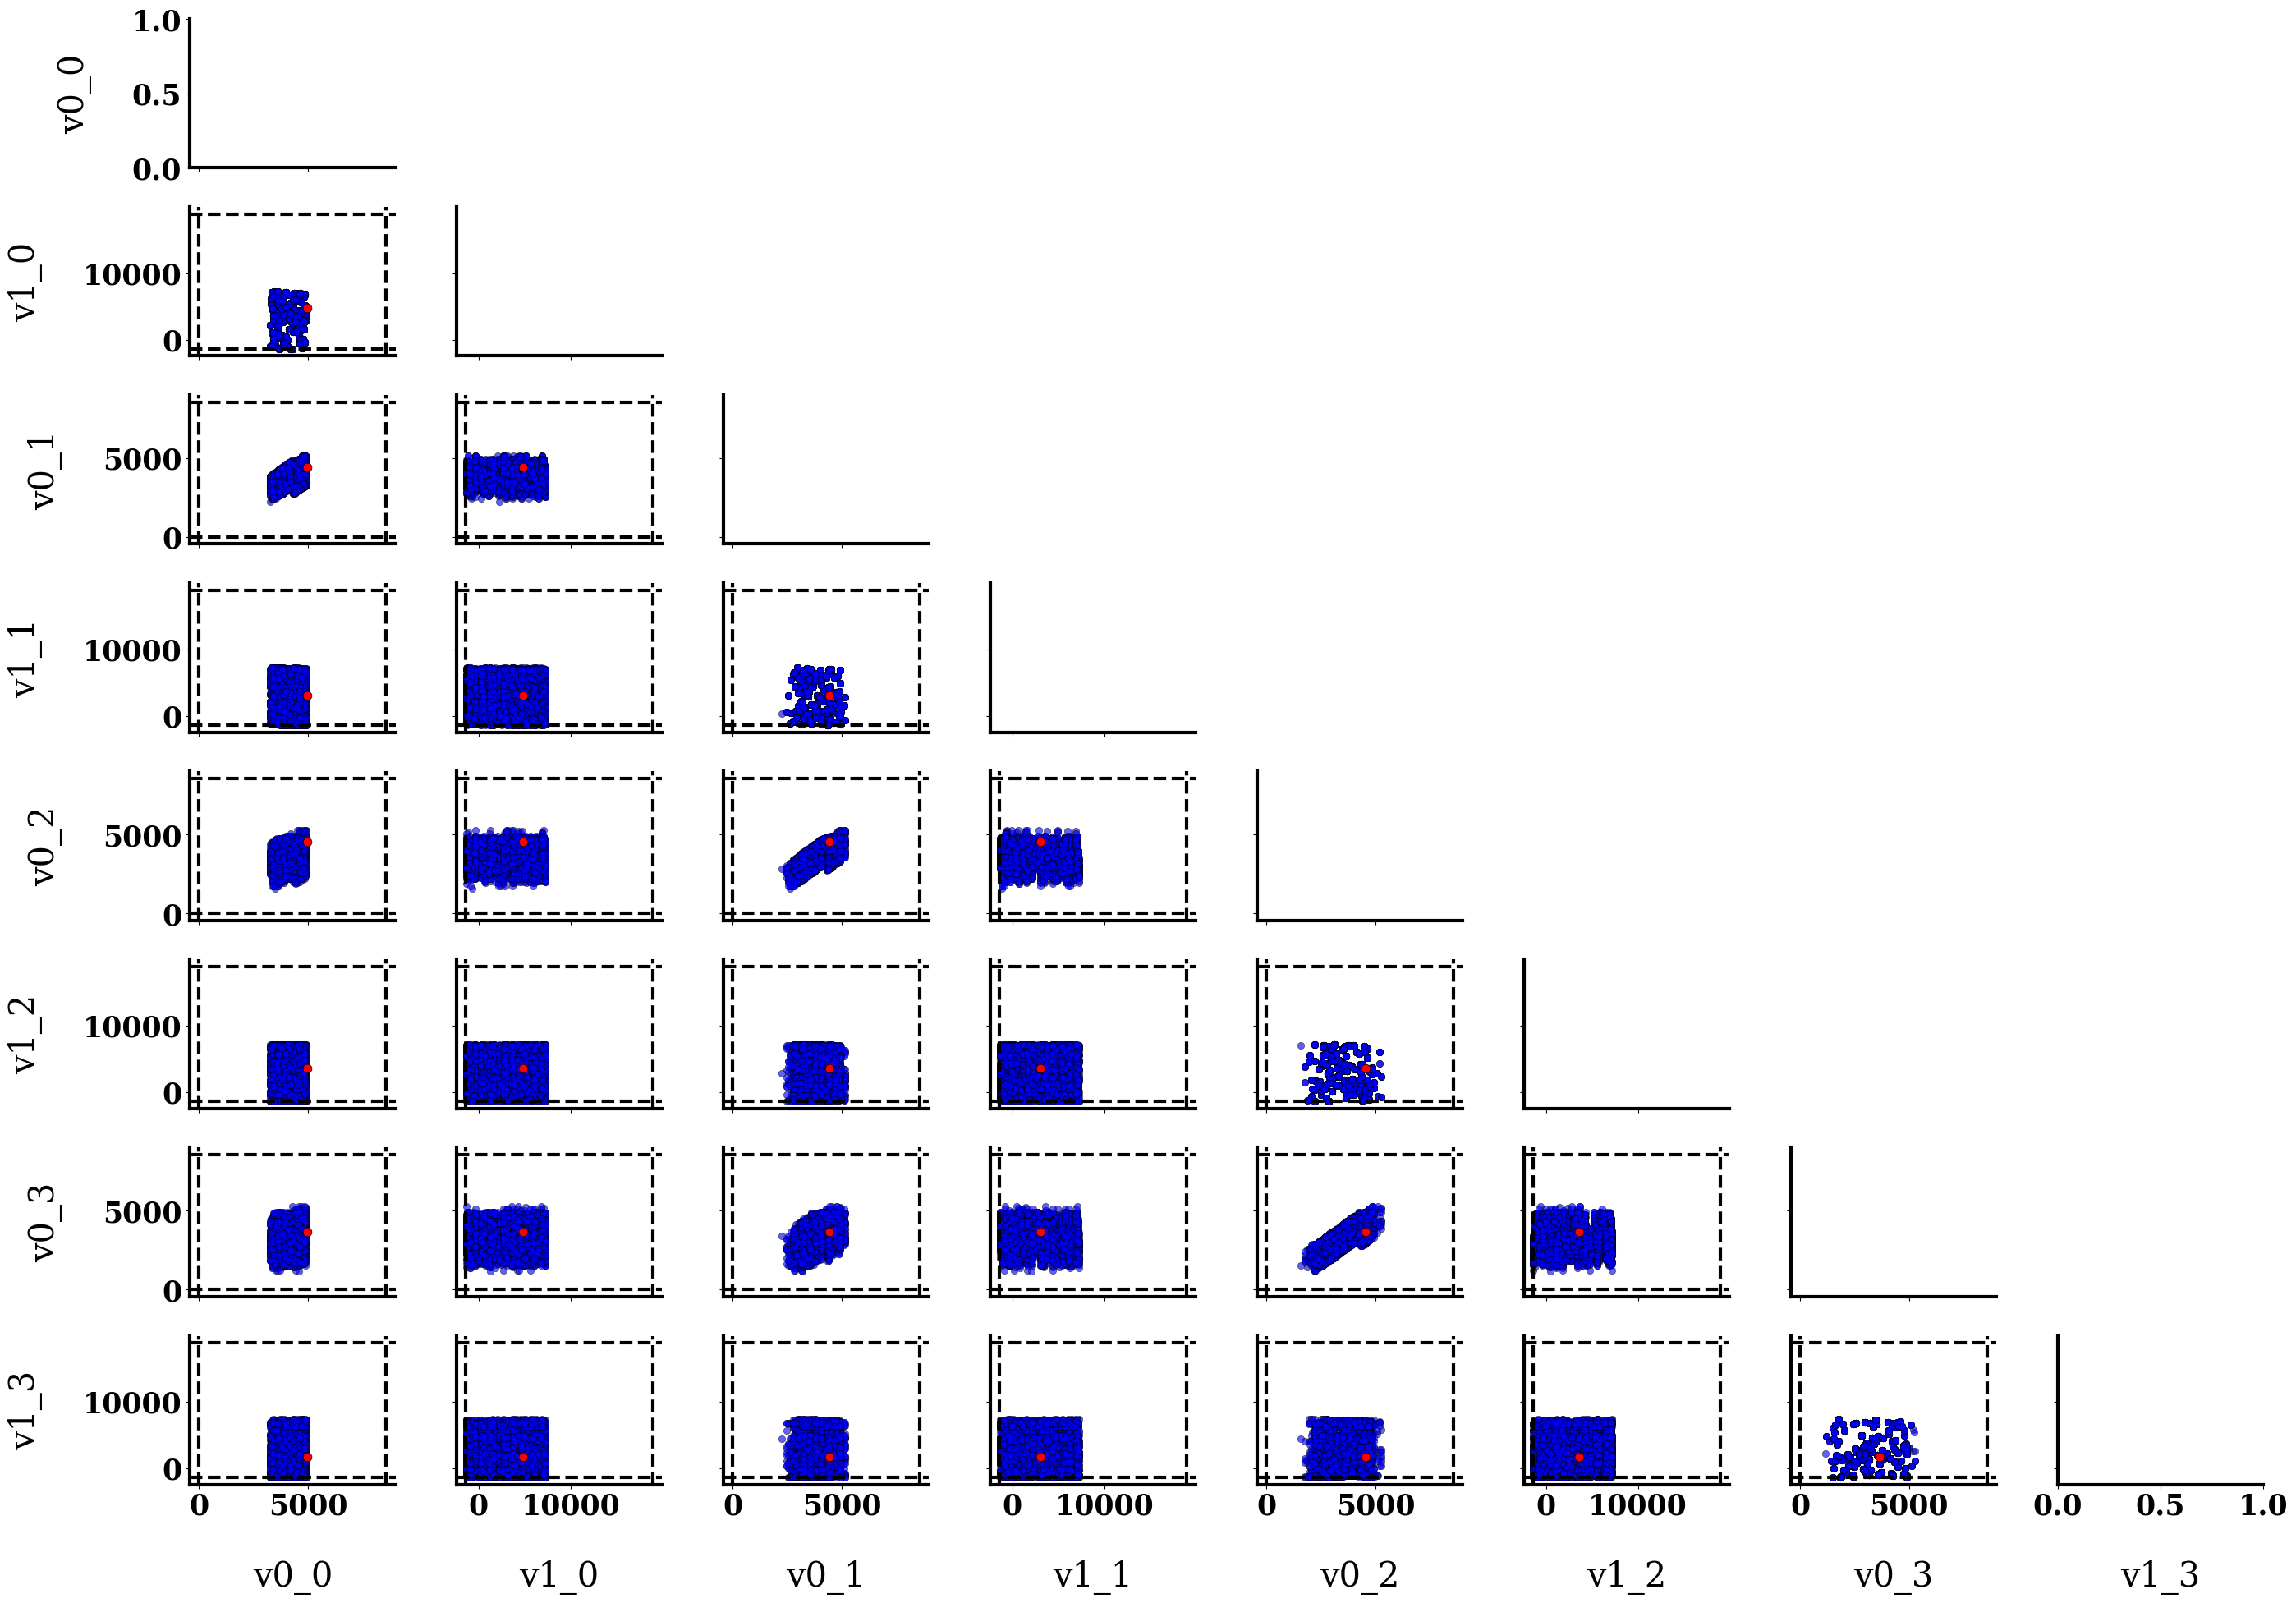

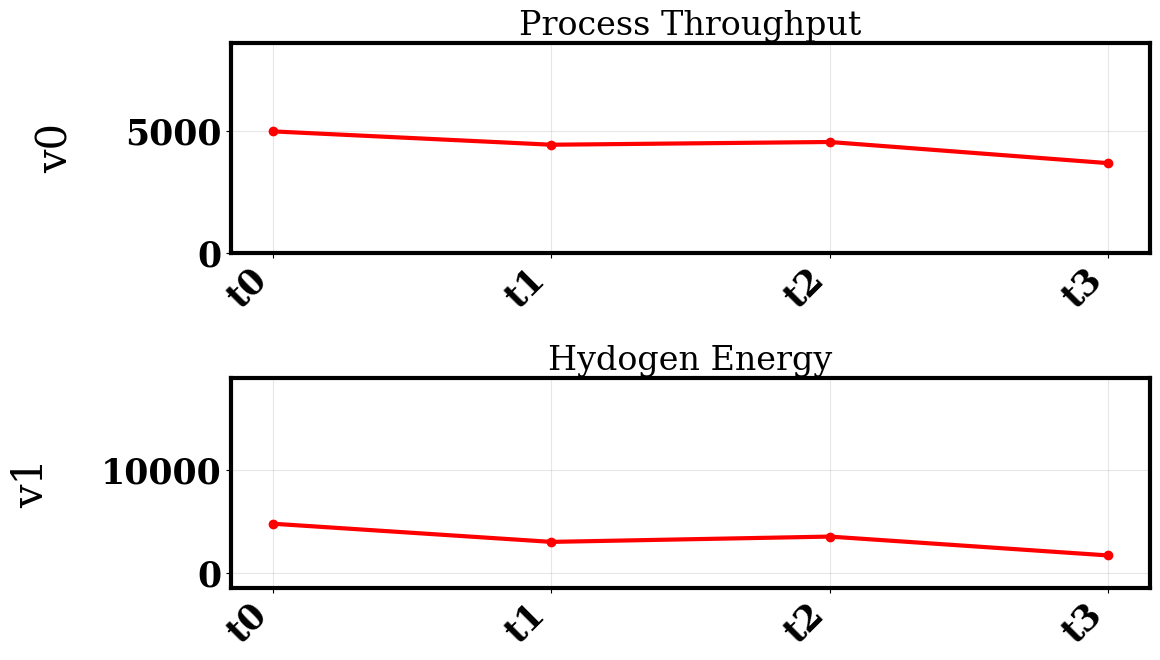

In [3]:

u = env.reset()

net_r = 0
count = 0
while True:
    v = agent.act(u)
    u, r, term, trunc, info = env.step(u, v, z=jnp.array([5.9]))
    
    net_r += r
    if term or trunc:
        print(term, trunc, net_r, info)
    count += 1
    if count == 4:
        break

agent.add_policy_to_plot()
_ = agent.plot_trajectories(['Process Throughput', 'Hydogen Energy'])


In [ ]:
_ = agent.plot_cost_colourmap()

deque([(0, Array([[4967.3745, 4827.9556]], dtype=float32)),
       (1, Array([[4420.8125, 3062.52  ]], dtype=float32)),
       (2, Array([[4532.7236, 3577.9075]], dtype=float32)),
       (3, Array([[3666.3667, 1744.1318]], dtype=float32))])